# Introduction to mf6rtm: the pyrite column

A first look at the modelling engine behind this whole curriculum. Before we tackle the field-scale DIZON model and its ~6 minute run cost, we will build a much smaller relative of it: a one-dimensional column of pyritic sand that we flush with oxic water. Same chemistry, same software, but small enough to write, run, and replot in seconds.

This is part0, so you can read it on its own. It sits alongside [the DIZON overview](../part0_01_intro_to_dizon/intro_to_dizon.ipynb) (the field experiment and the decision question) and is the foundation for [building the full model](../part1_01_build_model/dizon_build_model.ipynb) in part1. If the API calls here look familiar later on, that is the point.

`mf6rtm` couples two engines: **MODFLOW 6** moves water and solutes (via the MODFLOW 6 API), and **PHREEQC** (through PhreeqcRM) does the geochemistry in every cell at every reaction step. The `mup3d` module is the Python wrapper we use to set up the chemistry, glue it to a flow-and-transport model, and run the coupled simulation.

### The chemistry, in miniature

The DIZON story is redox. Pre-treated surface water carrying dissolved oxygen (and a little nitrate) is pushed into an aquifer whose sand grains are coated in **pyrite** (FeS₂), an iron sulfide that has sat happily in anoxic conditions for a very long time. The oxidant front meets the pyrite and the pyrite oxidises:

$$\mathrm{FeS_2 + \tfrac{15}{4}\,O_2 + \tfrac{7}{2}\,H_2O \;\rightarrow\; Fe(OH)_3 + 2\,SO_4^{2-} + 4\,H^+}$$

So where oxygen is consumed, **sulfate is produced**, **acid is released** (the 4 H⁺), and **iron** is mobilised (some of it reprecipitates as ferrihydrite). Sulfate is the species the whole curriculum is judged on, because at the supply well its concentration sets how much treatment the supplied water needs — and treatment cost scales with that concentration.

The column we build here strips DIZON down to this one reaction network: a background anoxic porewater in contact with pyrite, calcite (the pH buffer) and an exchanger, flushed with oxic injectate. The oxidant is consumed within the first metre or so of the column — the reaction is fast enough that the oxic front barely moves — but its *products* travel on with the flow, and we will watch them break through at the outlet.

### Admin

We start with the usual imports. `flopy` builds the MODFLOW 6 flow and transport models; `mf6rtm` (the `utils` helpers and the `mup3d` model class) builds the chemistry and runs the coupled simulation. The database file `datab.dat` that PHREEQC needs lives in the repository's `data/` folder; we reference it with a relative path and copy it into the model workspace at write time.

A couple of `assert`s confirm we are using the vendored `dependencies/` copies of `flopy` and `pyemu` rather than whatever else might be on your system.

In [1]:
import os
import sys
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import flopy
import pyemu
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__

from mf6rtm import utils, mup3d

sys.path.insert(0, "..")
import herebedragons as hbd

plt.rcParams["font.size"] = 10

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


Everything this notebook produces is written **inside this notebook's own directory**, into a workspace we will (re)create from scratch each time. Nothing is written back into `data/`.

In [2]:
# relative path to the PHREEQC thermodynamic database (lives in the repo's data/ dir)
database = os.path.join("..", "..", "data", "datab.dat")
assert os.path.exists(database), f"could not find the database at {database}"

# base workspace for the column model; recreated fresh below for each run
ws_base = "column"


## A one-dimensional flow model

The column is the simplest grid we can get away with: a single layer, a single row, and a string of cells along the flow direction. We make each cell 0.1 m long, so 40 cells gives a 4 m column. Water enters at the first cell and leaves at the last.

We will wrap the whole build in a function, `build_column(...)`, so that later we can rebuild it with a different injectate temperature without copy-pasting. Read it through once; the flow part is ordinary MODFLOW 6.

In [3]:
# column geometry (shared by every build)
nlay, nrow, ncol = 1, 1, 40   # a 1D column of 40 cells
delr = 0.1                    # cell length along flow (m) -> 4 m column
delc = 1.0                    # cell width (m)
top = 1.0
botm = 0.0

ne = 0.35       # effective porosity (-)
q_in = 0.1      # injection rate into the first cell (m^3/d)
# pore velocity v = q_in / (delc*thickness*ne) ~ 0.29 m/d, so the injectate
# sweeps the 4 m column in ~14 days: a couple of pore volumes pass in the 40-day
# run, enough to drive the reaction products to the outlet (the oxidant front
# itself is consumed long before it gets there -- see below)

In [4]:
def build_flow(ws):
    """Build a 1D MODFLOW 6 flow model: inject at cell 0, fixed head at the outlet."""
    sim = flopy.mf6.MFSimulation(sim_name="gwf", sim_ws=ws, exe_name="mf6")

    # 40 stress periods of 1 day each: time enough for a front to break through
    nper = 40
    perioddata = [(1.0, 1, 1.0) for _ in range(nper)]
    flopy.mf6.ModflowTdis(sim, time_units="DAYS", nper=nper, perioddata=perioddata)
    ims = flopy.mf6.ModflowIms(sim, complexity="complex", filename="gwf.ims",
                               outer_dvclose=1e-6, inner_dvclose=1e-6)

    gwf = flopy.mf6.ModflowGwf(sim, modelname="gwf", save_flows=True)
    sim.register_ims_package(ims, ["gwf"])
    flopy.mf6.ModflowGwfdis(gwf, nlay=nlay, nrow=nrow, ncol=ncol,
                            delr=delr, delc=delc, top=top, botm=botm)
    flopy.mf6.ModflowGwfic(gwf, strt=top)
    flopy.mf6.ModflowGwfnpf(gwf, icelltype=0, k=1.0, save_specific_discharge=True)
    flopy.mf6.ModflowGwfsto(gwf, ss=1e-5, iconvert=0, transient={0: True})

    # hold a fixed head at the outlet; the injection well is added in build_transport
    # (it needs the chemical components as auxiliaries, which we don't know yet)
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data={0: [[(0, 0, ncol - 1), top]]},
                            pname="chd")

    flopy.mf6.ModflowGwfoc(gwf, head_filerecord="gwf.hds",
                           saverecord=[("HEAD", "ALL")])
    return sim, gwf


## The chemistry

Now the interesting part. `mup3d` builds a PHREEQC input from a handful of Python objects, one per geochemical concept. We define them in the order PHREEQC reasons about them:

1. **Solutions** — the water chemistry: the background porewater and the injectate.
2. **Equilibrium phases** — minerals assumed to react instantly to equilibrium (here calcite and ferrihydrite).
3. **Kinetic phases** — minerals that react at a finite, rate-controlled pace (here pyrite — the slow oxidation is the whole story).
4. **Exchanger** — cations held on the sediment surface, which buffer the porewater as the front passes.

Each object takes a dictionary keyed by a *solution number* (or layer), and each is given an "initial conditions" array the same shape as the grid that says which definition applies in which cell. The numbers below are cribbed straight from the field-scale DIZON build — this really is the same chemistry, just on a smaller grid.

### Solutions

We define two solutions. **Solution 1** is the background porewater: anoxic (essentially no O₂), circum-neutral, carrying the dissolved products of being in long contact with the sediment. **Solution 2** is the injectate: oxygen-bearing, slightly acidic surface water with very little of the reduced species.

Concentrations are in mol/kgw. `pH` and `pe` are passed through as-is; `Tmp` is a transported temperature "tracer" stored as °C/1000 (so 0.017 is ~17 °C) — the pyrite rate law reads it back to set the temperature dependence, which we will exploit at the end.

In [5]:
# species -> [solution 1 (background porewater), solution 2 (oxic injectate)]
# concentrations in mol/kgw; cribbed from the DIZON field-scale build
solution_data = {
    "O(0)":   [1.0e-18, 5.19e-04],   # dissolved oxygen: anoxic background vs oxic injectate
    "C(+4)":  [8.45e-03, 2.28e-03],  # dissolved inorganic carbon
    "Ca":     [2.06e-03, 1.77e-03],
    "Cl":     [2.54e-04, 2.48e-03],  # conservative tracer
    "Fe(+2)": [9.51e-05, 1.0e-18],
    "K":      [1.34e-04, 1.48e-04],
    "Mg":     [5.89e-04, 3.91e-04],
    "N(+5)":  [1.0e-18, 2.66e-04],   # nitrate: a second oxidant in the injectate
    "Na":     [6.80e-04, 1.78e-03],
    "S(6)":   [5.51e-05, 7.19e-04],  # sulfate
    "Si":     [3.50e-04, 1.78e-05],
    "Tmp":    [0.017, 0.017],        # temperature tracer (deg C / 1000) ~ 17 deg C
    "pH":     [6.67, 7.30],
    "pe":     [-2.88, 4.0],          # anoxic (low pe) vs oxic (high pe) injectate
}


In [6]:
def build_solutions():
    """Background porewater (solution 1) everywhere; injectate (solution 2) is wired in via the well."""
    soldf = pd.DataFrame(solution_data, index=[1, 2]).T  # rows=species, cols=solution number
    solutions_dict = utils.solution_df_to_dict(soldf)
    solutions = mup3d.Solutions(solutions_dict)
    # initial condition: every cell starts as the background porewater (solution 1)
    sol_ic = np.ones((nlay, nrow, ncol), dtype=float)
    solutions.set_ic(sol_ic)
    return solutions, sol_ic


### Equilibrium phases

Calcite and ferrihydrite are treated as equilibrium phases: PHREEQC keeps the porewater in equilibrium with them at every step. Calcite is the **pH buffer** — as pyrite oxidation generates acid, calcite dissolves to neutralise it. Ferrihydrite is the iron-oxide sink that catches the Fe(III) released by oxidation; we start it at zero moles so it can only ever precipitate.

Each phase carries a saturation index (`si`, here 0 — start at equilibrium) and an initial amount in moles (`m0`).

In [7]:
def build_equilibrium():
    """Calcite (pH buffer) and ferrihydrite (Fe(III) sink), as equilibrium phases."""
    eq_dic = {
        0: {
            "Calcite":      {"si": 0.0, "m0": 0.5},   # plenty of buffer
            "Ferrihydrite": {"si": 0.0, "m0": 0.0},   # starts absent; can only precipitate
        }
    }
    equilibriums = mup3d.EquilibriumPhases(eq_dic)
    equilibriums.set_ic(np.ones((nlay, nrow, ncol), dtype=float))
    return equilibriums


### Kinetic phases: pyrite

Pyrite oxidation is **slow** relative to groundwater flow, so it is modelled as a kinetic reaction rather than an equilibrium one. The rate law (defined in `datab.dat`, after Williamson & Rimstidt 1994 and Appelo et al. 1998) takes four parameters:

| parm | meaning |
|---|---|
| `parm(1)` | log₁₀ of reactive surface area per volume |
| `parm(2)` | exponent on the remaining pyrite fraction (m/m₀) |
| `parm(3)` | exponent on oxidant concentration (O₂, NO₃⁻) |
| `parm(4)` | exponent on H⁺ |

The same rate law also reads the temperature tracer `Tmp` and applies an **Arrhenius factor** normalised to 14 °C — warmer water oxidises pyrite faster. That temperature dependence is DIZON's headline, and we will demonstrate it in the last section.

`m0` is the initial moles of pyrite available to react (per litre of porewater). This abundance and the rate are exactly the "reaction tier" of the [layered prior](../../CONTEXT.md) we will later treat as uncertain.

In [8]:
# four pyrite rate-law parameters (from the DIZON build):
# log10(A/V), (m/m0) exponent, oxidant exponent, H+ exponent
kin_py_params = [16.0, 0.67, 0.5, -0.11]

def build_kinetics():
    """Pyrite as a kinetic phase, with the temperature-dependent oxidation rate law."""
    kin_dic = {
        0: {
            "Pyrite": {
                "m0": 0.1,                 # initial pyrite (mol per L porewater)
                "parms": kin_py_params,
            }
        }
    }
    kinetics = mup3d.KineticPhases(kin_dic)
    kinetics.set_ic(np.ones((nlay, nrow, ncol), dtype=float))
    return kinetics


### Exchanger

The sediment surface holds exchangeable cations (CaX₂, FeX₂, KX, MgX₂, NaX). As the injectate sweeps through, these exchange with the porewater and damp the chemical swings — a real and often-overlooked control on breakthrough shape. We give the exchanger initial moles per cation and tell it to equilibrate against the background solution (solution 1).

In [9]:
def build_exchanger():
    """Cation exchanger, equilibrated against the background porewater."""
    exchanger_dict = {
        0: {
            "CaX2": {"m0": 0.0589},
            "FeX2": {"m0": 0.00078},
            "KX":   {"m0": 0.00078},
            "MgX2": {"m0": 0.0106},
            "NaX":  {"m0": 0.00080},
        }
    }
    exchanger = mup3d.ExchangePhases(exchanger_dict)
    exchanger.set_ic(np.ones((nlay, nrow, ncol), dtype=float))
    exchanger.set_equilibrate_solutions([1])  # equilibrate with solution 1
    return exchanger


## Assembling the coupled model

With the chemistry objects in hand we build the `Mup3d` model, point it at the database and the output postfix, attach each phase, and `initialize()` it. Initialising runs PHREEQC once to equilibrate the initial conditions and work out which chemical **components** must be transported — that component list is what tells the transport model how many species to carry.

The postfix file (`postfix.phqr`, also in `data/`) is a PHREEQC `SELECTED_OUTPUT` block: it lists exactly which quantities get punched to the output table (`sout.csv`) each reaction step — the species concentrations, pH, pe, and mineral amounts we want to plot.

In [10]:
def build_chemistry(ws):
    """Assemble the mup3d chemistry model in workspace `ws` and initialize it."""
    solutions, sol_ic = build_solutions()

    model = mup3d.Mup3d("column", solutions, nlay=nlay, nrow=nrow, ncol=ncol)
    model.set_wd(ws)

    # register the database (set_database copies it into the workspace for us)
    # and the output postfix that controls what gets written to sout.csv
    model.set_database(database)
    model.set_postfix(os.path.join("..", "..", "data", "postfix.phqr"))

    # attach the phases (order does not matter; mup3d sorts them into the script)
    model.set_equilibrium_phases(build_equilibrium())
    model.set_phases(build_kinetics())
    model.set_exchange_phases(build_exchanger())

    # run reactions every step; write external IO so MODFLOW 6 and PHREEQC can talk
    perlen = [(1.0, 1, 1.0)] * 40
    tsteps = hbd.create_reactive_tsteps(perlen, output_interval=1)
    model.set_config(reactive={"timing": "user", "externalio": True, "tsteps": tsteps})
    model.set_componenth2o(True)

    model.initialize(add_charge_flag=False)
    return model


### Wiring the injectate to the inlet

`build_chemistry` worked out the component list (`model.components`). The injectate (solution 2) reaches the column through the injection well, so we wrap it in a `ChemStress` keyed to that well. Initialising the chem stress runs PHREEQC once more and hands back the injectate concentrations (in mol/m³) ordered to match `model.components` — exactly the order MODFLOW 6 wants the well auxiliaries in.

In [11]:
def make_injection_well(gwf, model):
    """Wrap solution 2 as a chem stress and build the injection well that carries it."""
    wellchem = mup3d.ChemStress("welin")
    wellchem.set_spd([2])               # solution 2 = the oxic injectate
    model.set_chem_stress(wellchem)
    inj_conc = wellchem.data[0]         # injectate concs (mol/m3), ordered by model.components

    # inject oxic water at the first cell, carrying each component's injectate concentration
    spd = {0: [[(0, 0, 0), q_in] + list(inj_conc)]}
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data=spd,
                            auxiliary=list(model.components), pname="welin")
    return inj_conc


Now one GWT (groundwater transport) model per component. Each component is advected and dispersed by the same flow field; PHREEQC then reacts them all together in every cell. The `ssm` package is what tells transport to pick up that component's concentration from the injection-well auxiliary.

In [12]:
def add_transport_models(sim, gwf, model):
    """Add a GWT model for every chemical component, coupled to the flow model."""
    long_disp = 0.005   # longitudinal dispersivity (m); small relative to the column

    for comp in model.components:
        gwt = flopy.mf6.MFModel(sim, model_type="gwt6", modelname=comp,
                                model_nam_file=f"{comp}.nam")
        ims = flopy.mf6.ModflowIms(sim, complexity="complex", filename=f"{comp}.ims",
                                   outer_dvclose=1e-6, inner_dvclose=1e-6)
        sim.register_ims_package(ims, [comp])

        flopy.mf6.ModflowGwtdis(gwt, nlay=nlay, nrow=nrow, ncol=ncol,
                                delr=delr, delc=delc, top=top, botm=botm)
        flopy.mf6.ModflowGwtic(gwt, strt=model.sconc[comp])  # PHREEQC's initial concs
        flopy.mf6.ModflowGwtadv(gwt, scheme="tvd")
        flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=long_disp,
                                ath1=long_disp * 0.1, atv=long_disp * 0.01)
        flopy.mf6.ModflowGwtmst(gwt, porosity=ne)
        flopy.mf6.ModflowGwtssm(gwt, sources=[["welin", "aux", comp]])
        flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord=f"{comp}.ucn",
                               saverecord=[("CONCENTRATION", "ALL")])
        flopy.mf6.ModflowGwfgwt(sim, exgtype="GWF6-GWT6",
                                exgmnamea="gwf", exgmnameb=comp,
                                filename=f"{comp}.gwfgwt")
    return sim


## Build, write and run

Now we tie it all together. `build_column` builds the flow model, the chemistry, and the transport, writes everything to disk, and (optionally) runs it via the API. The `model.run()` call drives MODFLOW 6 and PHREEQC together through the coupled time loop — no external executable is shelled out for the reactions; it all happens inside the process through the libraries.

We copy the platform binaries (the `mf6` executable and the `libmf6` shared library) into the workspace first with `hbd.get_bins`, so the API can find them.

In [13]:
def build_column(ws, injectate_temp_c=17.0, run=True):
    """Build, write and (optionally) run the pyrite column.

    Parameters
    ----------
    ws : str
        Workspace directory (created fresh).
    injectate_temp_c : float
        Temperature of the oxic injectate in degrees C (feeds the pyrite rate law).
    run : bool
        If True, run the coupled simulation via the MODFLOW 6 / PHREEQC API.
    """
    if os.path.exists(ws):
        shutil.rmtree(ws)
    os.makedirs(ws)

    # set the injectate temperature tracer (stored as deg C / 1000)
    solution_data["Tmp"][1] = injectate_temp_c / 1000.0

    sim, gwf = build_flow(ws)
    model = build_chemistry(ws)
    make_injection_well(gwf, model)
    add_transport_models(sim, gwf, model)

    sim.write_simulation()   # write the MODFLOW 6 flow + transport files
    model.write_simulation() # write the PHREEQC input + coupling config

    # copy mf6 + libmf6 into the workspace so the API can find them
    hbd.get_bins(ws)

    success = None
    if run:
        success = model.run()
    return model, success


Run it. On a laptop the column finishes in a few seconds — compare that with the ~6 minutes a single full-scale DIZON run costs. That contrast is exactly why this column is also the curriculum's fast regression-test model, and why later notebooks lean so hard on emulation.

(Press `shift+enter` to run the cell.)

In [14]:
model, success = build_column(os.path.join(ws_base, "warm"), injectate_temp_c=17.0, run=True)
print("run succeeded:", success)


Using temperatue of 25.0 for all cells
Writing external files for exchange_phases     : CaX2
Writing external files for exchange_phases     : FeX2
Writing external files for exchange_phases     : KX
Writing external files for exchange_phases     : MgX2
Writing external files for exchange_phases     : NaX
Writing external files for equilibrium_phases  : Calcite
Writing external files for equilibrium_phases  : Ferrihydrite
Writing external files for kinetic_phases      : Pyrite
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: user
  External files flag: True
  Emulator flag: False
  User-defined time steps (40 total):
    Period 1, Step 1
    Period 2, Step 1
    Period 3, Step 1
    Period 4, Step 1
    Period 5, Step 1
    Period 6, Step 1
    Period 7, Step 1
    Period 8, Step 1
    Period 9, Step 1
    Period 10, Step 1
    Period 11, Step 1
    Period 12, Step 1
    Period 13, Step 1
    Period 14, Step 1
    Period 15, Step 1
    Period 16, Ste

Using libmf6 found in model directory: libmf6.dylib


Processing initial chemistry configuration
  Period 1, Time step 1
  Period 2, Time step 1
  Period 3, Time step 1
  Period 4, Time step 1
  Period 5, Time step 1
  Period 6, Time step 1
  Period 7, Time step 1
  Period 8, Time step 1
  Period 9, Time step 1
  Period 10, Time step 1
  Period 11, Time step 1
  Period 12, Time step 1
  Period 13, Time step 1
  Period 14, Time step 1
  Period 15, Time step 1
  Period 16, Time step 1
  Period 17, Time step 1
  Period 18, Time step 1
  Period 19, Time step 1
  Period 20, Time step 1
  Period 21, Time step 1
  Period 22, Time step 1
  Period 23, Time step 1
  Period 24, Time step 1
  Period 25, Time step 1
  Period 26, Time step 1
  Period 27, Time step 1
  Period 28, Time step 1
  Period 29, Time step 1
  Period 30, Time step 1
  Period 31, Time step 1
  Period 32, Time step 1
  Period 33, Time step 1
  Period 34, Time step 1
  Period 35, Time step 1
  Period 36, Time step 1
  Period 37, Time step 1
  Period 38, Time step 1
  Period 39, Tim

Transport       | Stress period:  7     | Time step:      1          | Completed in :  0 min   1.32e-06 sec
Reactions       | Stress period:  7     | Time step:      1          | Completed in :  0 min   2.99e-04 sec
Transport       | Stress period:  8     | Time step:      1          | Completed in :  0 min   1.05e-06 sec
Reactions       | Stress period:  8     | Time step:      1          | Completed in :  0 min   3.03e-04 sec
Transport       | Stress period:  9     | Time step:      1          | Completed in :  0 min   1.08e-06 sec
Reactions       | Stress period:  9     | Time step:      1          | Completed in :  0 min   3.12e-04 sec
Transport       | Stress period:  10    | Time step:      1          | Completed in :  0 min   1.07e-06 sec
Reactions       | Stress period:  10    | Time step:      1          | Completed in :  0 min   3.26e-04 sec
Transport       | Stress period:  11    | Time step:      1          | Completed in :  0 min   1.12e-06 sec
Reactions       | Stress per


Transport       | Stress period:  13    | Time step:      1          | Completed in :  0 min   1.05e-06 sec
Reactions       | Stress period:  13    | Time step:      1          | Completed in :  0 min   4.40e-04 sec
Transport       | Stress period:  14    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  14    | Time step:      1          | Completed in :  0 min   4.30e-04 sec
Transport       | Stress period:  15    | Time step:      1          | Completed in :  0 min   1.15e-06 sec
Reactions       | Stress period:  15    | Time step:      1          | Completed in :  0 min   4.38e-04 sec
Transport       | Stress period:  16    | Time step:      1          | Completed in :  0 min   1.13e-06 sec
Reactions       | Stress period:  16    | Time step:      1          | Completed in :  0 min   4.84e-04 sec
Transport       | Stress period:  17    | Time step:      1          | Completed in :  0 min   1.13e-06 sec


...

Reactions       | Stress period:  22    | Time step:      1          | Completed in :  0 min   5.02e-04 sec
Transport       | Stress period:  23    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  23    | Time step:      1          | Completed in :  0 min   5.10e-04 sec
Transport       | Stress period:  24    | Time step:      1          | Completed in :  0 min   1.12e-06 sec
Reactions       | Stress period:  24    | Time step:      1          | Completed in :  0 min   5.12e-04 sec
Transport       | Stress period:  25    | Time step:      1          | Completed in :  0 min   1.07e-06 sec
Reactions       | Stress period:  25    | Time step:      1          | Completed in :  0 min   5.38e-04 sec
Transport       | Stress period:  26    | Time step:      1          | Completed in :  0 min   1.18e-06 sec
Reactions       | Stress period:  26    | Time step:      1          | Completed in :  0 min   5.17e-04 sec


Transport       | Stress period:  27    | Time step:      1          | Completed in :  0 min   1.12e-06 sec
Reactions       | Stress period:  27    | Time step:      1          | Completed in :  0 min   5.21e-04 sec
Transport       | Stress period:  28    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  28    | Time step:      1          | Completed in :  0 min   5.17e-04 sec
Transport       | Stress period:  29    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  29    | Time step:      1          | Completed in :  0 min   5.09e-04 sec
Transport       | Stress period:  30    | Time step:      1          | Completed in :  0 min   1.08e-06 sec
Reactions       | Stress period:  30    | Time step:      1          | Completed in :  0 min   5.09e-04 sec
Transport       | Stress period:  31    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress per

Transport       | Stress period:  32    | Time step:      1          | Completed in :  0 min   1.15e-06 sec
Reactions       | Stress period:  32    | Time step:      1          | Completed in :  0 min   5.30e-04 sec
Transport       | Stress period:  33    | Time step:      1          | Completed in :  0 min   1.15e-06 sec
Reactions       | Stress period:  33    | Time step:      1          | Completed in :  0 min   5.38e-04 sec
Transport       | Stress period:  34    | Time step:      1          | Completed in :  0 min   1.12e-06 sec
Reactions       | Stress period:  34    | Time step:      1          | Completed in :  0 min   5.38e-04 sec
Transport       | Stress period:  35    | Time step:      1          | Completed in :  0 min   1.08e-06 sec
Reactions       | Stress period:  35    | Time step:      1          | Completed in :  0 min   5.03e-04 sec
Transport       | Stress period:  36    | Time step:      1          | Completed in :  0 min   1.12e-06 sec


Reactions       | Stress period:  36    | Time step:      1          | Completed in :  0 min   5.19e-04 sec
Transport       | Stress period:  37    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  37    | Time step:      1          | Completed in :  0 min   5.10e-04 sec
Transport       | Stress period:  38    | Time step:      1          | Completed in :  0 min   1.07e-06 sec
Reactions       | Stress period:  38    | Time step:      1          | Completed in :  0 min   5.11e-04 sec
Transport       | Stress period:  39    | Time step:      1          | Completed in :  0 min   1.10e-06 sec
Reactions       | Stress period:  39    | Time step:      1          | Completed in :  0 min   5.19e-04 sec
Transport       | Stress period:  40    | Time step:      1          | Completed in :  0 min   1.12e-06 sec
Reactions       | Stress period:  40    | Time step:      1          | Completed in :  0 min   5.16e-04 sec

Transport converged success


.................,,,,,,,,,,,.,,.......,,,,,,,.,,,,,,,,,,,,,,,,,,,,....
................,,,,,,,,,,,.,,,,......,,,,,,..,,,,,,,,,,...,,,,,,,....
...........,,,,,.,,,,,,,,,,.,,,,.....,..,,,,.,,,,,,.....,,,,,,,.......
.............,,,,,,,,,,,,,,,,,,..,.....,,...,,,,.....,,,,,,,,,,.......
...............,,,,,,,,,,,,,,,,,,,,.,,,,...,,,,,..,,,,,,,,,,,.........
....................,,,,,,,,,,,,,,,,,,,,,,,,,,,.......................
.....................,,,,,,,,,,,,,,,,,,,,,,,,.........................
.....................,,..??????.............??????...................,
......................????????????....????????????...................,
....................???????????????,.?????????????...................,
...................????????????????.???????????????.................,,
....................?????,%%%??????.????????????????................,,
....................?????.%%,??????,??????%%%,?????.................,,
.......................??????????.%%..????,%%.?????................,,,
.....

## Reading the breakthrough

The reaction output is punched to `sout.csv` in the workspace: one row per cell per reaction step, with a column per quantity listed in the postfix. The column headings come straight from that postfix — `SO4`, `O0` (dissolved O₂), `pH`, `Fe`, the mineral amounts, and so on. We load it and pick out the **outlet cell** (the last cell, `cell` index `ncol - 1`) to see what comes out the end of the column.

Watch the oxygen: it never reaches the outlet, because pyrite oxidation consumes it within the first metre. What arrives instead is the *signature* of that reaction, carried downstream by the flow.

In [15]:
def read_sout(ws):
    """Load the reaction output table and return the outlet-cell breakthrough."""
    sout = pd.read_csv(os.path.join(ws, "sout.csv"))
    sout = sout.mask(sout >= 1e30, np.nan)
    outlet = sout[sout["cell"] == ncol - 1].sort_values("time")
    return outlet

warm = read_sout(os.path.join(ws_base, "warm"))
warm.head()


,time,cell,Orgc,O0,tic,C_4,Ca,Cl,Fe,Fe2,...,pe,EQUI_Ferrihydrite,EQUI_Orgmatter,MOL_CaX2,MOL_FeX2,MOL_KX,MOL_MgX2,MOL_NaX,KIN_Pyrite,HCO3
39,1.0,39.0,0.0,0.0,0.009036,3.084787e-37,0.002492,0.000254,0.000113,0.000113,...,0.417138,0.000000e+00,0.0,0.058893,0.001204,0.000764,0.010427,0.00075,0.1,0.006925
79,3.0,39.0,0.0,0.0,0.009036,0.000000e+00,0.002492,0.000254,0.000113,0.000113,...,1.076942,0.000000e+00,0.0,0.058893,0.001204,0.000764,0.010427,0.00075,0.1,0.006925
119,4.0,39.0,0.0,0.0,0.009036,0.000000e+00,0.002492,0.000254,0.000113,0.000113,...,1.425209,0.000000e+00,0.0,0.058893,0.001204,0.000764,0.010427,0.00075,0.1,0.006925
159,5.0,39.0,0.0,0.0,0.009035,0.000000e+00,0.002492,0.000255,0.000113,0.000113,...,1.477788,7.897399e-09,0.0,0.058893,0.001204,0.000764,0.010427,0.00075,0.1,0.006924
199,6.0,39.0,0.0,0.0,0.009030,0.000000e+00,0.002493,0.000259,0.000113,0.000113,...,1.477357,2.349411e-08,0.0,0.058893,0.001204,0.000764,0.010427,0.00075,0.1,0.006921


We will plot the breakthrough of the four species that tell the redox story: dissolved oxygen (`O0`), sulfate (`SO4`), pH, and iron (`Fe`). A small helper draws all four, and can overlay more than one run — which we will need shortly.

In [16]:
def plot_breakthrough(dfs, labels):
    """Plot O2, SO4, pH and Fe at the column outlet for one or more runs."""
    panels = [("O0", "O$_2$ (mol/L)"), ("SO4", "SO$_4$ (mol/L)"),
              ("pH", "pH"), ("Fe", "Fe (mol/L)")]
    fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
    for ax, (col, ylab) in zip(axs.flatten(), panels):
        for df, lab in zip(dfs, labels):
            ax.plot(df["time"], df[col], marker=".", ms=4, label=lab)
        ax.set_ylabel(ylab)
        ax.set_xlabel("time (days)")
    axs[0, 0].legend()
    fig.suptitle("Breakthrough at the column outlet")
    fig.tight_layout()
    return fig


Plot the warm run. We expect the reaction's downstream signature to arrive over the second half of the run — sulfate rising as upstream pyrite oxidation feeds it, pH climbing toward the (alkaline, calcite-buffered) injectate value, and iron rising then falling as conditions change. Oxygen stays at zero throughout: it is spent before it gets here.

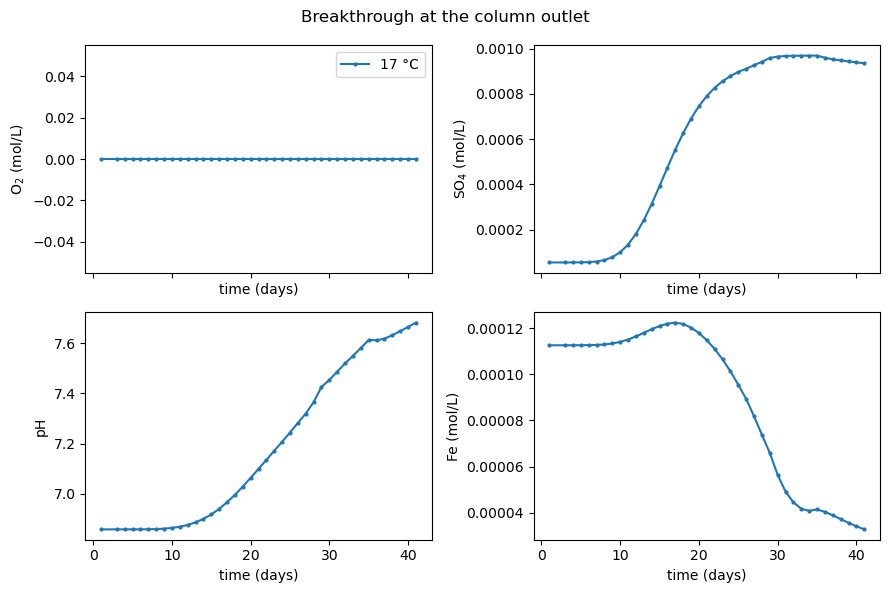

In [17]:
plot_breakthrough([warm], ["17 °C"])
plt.show()


Read it as the reaction's footprint arriving at the outlet. No oxygen comes through — it is consumed at the front, upstream. Sulfate climbs as pyrite oxidation upstream feeds it and the product plume reaches the end of the column; pH rises toward the calcite-buffered injectate value (the acid the reaction makes is neutralised, and the injectate is more alkaline than the background porewater); iron rises then falls as the dissolution-and-reprecipitation balance shifts. This is DIZON's redox story in a single column — the same story that, at field scale, sets how much sulfate the supply well delivers, and so how much treatment the supplied water needs.

## Warm versus cold injectate

Pyrite oxidation is temperature-dependent: the rate law carries an Arrhenius factor, so warmer water drives faster oxidation and more sulfate per unit of oxidant consumed. Temperature is also why DIZON carries `Tmp` as a conditioning species — it is a tracer of velocity *and* a control on the reaction rate.

To see it, we rebuild the column with a colder injectate and overlay the breakthrough. Nothing changes but the injectate temperature.

In [18]:
model_cold, success_cold = build_column(os.path.join(ws_base, "cold"),
                                        injectate_temp_c=7.0, run=True)
print("cold run succeeded:", success_cold)
cold = read_sout(os.path.join(ws_base, "cold"))


Using temperatue of 25.0 for all cells
Writing external files for exchange_phases     : CaX2
Writing external files for exchange_phases     : FeX2
Writing external files for exchange_phases     : KX
Writing external files for exchange_phases     : MgX2
Writing external files for exchange_phases     : NaX
Writing external files for equilibrium_phases  : Calcite
Writing external files for equilibrium_phases  : Ferrihydrite
Writing external files for kinetic_phases      : Pyrite
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: user
  External files flag: True
  Emulator flag: False
  User-defined time steps (40 total):
    Period 1, Step 1
    Period 2, Step 1
    Period 3, Step 1
    Period 4, Step 1
    Period 5, Step 1
    Period 6, Step 1
    Period 7, Step 1
    Period 8, Step 1
    Period 9, Step 1
    Period 10, Step 1
    Period 11, Step 1
    Period 12, Step 1
    Period 13, Step 1
    Period 14, Step 1
    Period 15, Step 1
    Period 16, Ste

Using libmf6 found in model directory: libmf6.dylib


Processing initial chemistry configuration
  Period 1, Time step 1
  Period 2, Time step 1
  Period 3, Time step 1
  Period 4, Time step 1
  Period 5, Time step 1
  Period 6, Time step 1
  Period 7, Time step 1
  Period 8, Time step 1
  Period 9, Time step 1
  Period 10, Time step 1
  Period 11, Time step 1
  Period 12, Time step 1
  Period 13, Time step 1
  Period 14, Time step 1
  Period 15, Time step 1
  Period 16, Time step 1
  Period 17, Time step 1
  Period 18, Time step 1
  Period 19, Time step 1
  Period 20, Time step 1
  Period 21, Time step 1
  Period 22, Time step 1
  Period 23, Time step 1
  Period 24, Time step 1
  Period 25, Time step 1
  Period 26, Time step 1
  Period 27, Time step 1
  Period 28, Time step 1
  Period 29, Time step 1
  Period 30, Time step 1
  Period 31, Time step 1
  Period 32, Time step 1
  Period 33, Time step 1
  Period 34, Time step 1
  Period 35, Time step 1
  Period 36, Time step 1
  Period 37, Time step 1
  Period 38, Time step 1
  Period 39, Tim

Reactions       | Stress period:  6     | Time step:      1          | Completed in :  0 min   2.62e-04 sec
Transport       | Stress period:  7     | Time step:      1          | Completed in :  0 min   8.08e-06 sec
Reactions       | Stress period:  7     | Time step:      1          | Completed in :  0 min   2.76e-04 sec
Transport       | Stress period:  8     | Time step:      1          | Completed in :  0 min   8.23e-06 sec
Reactions       | Stress period:  8     | Time step:      1          | Completed in :  0 min   2.74e-04 sec
Transport       | Stress period:  9     | Time step:      1          | Completed in :  0 min   8.83e-06 sec
Reactions       | Stress period:  9     | Time step:      1          | Completed in :  0 min   2.81e-04 sec
Transport       | Stress period:  10    | Time step:      1          | Completed in :  0 min   8.20e-06 sec
Reactions       | Stress period:  10    | Time step:      1          | Completed in :  0 min   3.04e-04 sec
Transport       | Stress per

Reactions       | Stress period:  12    | Time step:      1          | Completed in :  0 min   3.15e-04 sec
Transport       | Stress period:  13    | Time step:      1          | Completed in :  0 min   7.45e-06 sec
Reactions       | Stress period:  13    | Time step:      1          | Completed in :  0 min   3.26e-04 sec
Transport       | Stress period:  14    | Time step:      1          | Completed in :  0 min   6.87e-06 sec
Reactions       | Stress period:  14    | Time step:      1          | Completed in :  0 min   3.33e-04 sec
Transport       | Stress period:  15    | Time step:      1          | Completed in :  0 min   6.28e-06 sec
Reactions       | Stress period:  15    | Time step:      1          | Completed in :  0 min   3.39e-04 sec
Transport       | Stress period:  16    | Time step:      1          | Completed in :  0 min   5.92e-06 sec
Reactions       | Stress period:  16    | Time step:      1          | Completed in :  0 min   4.20e-04 sec
Transport       | Stress per

Transport       | Stress period:  18    | Time step:      1          | Completed in :  0 min   7.72e-06 sec
Reactions       | Stress period:  18    | Time step:      1          | Completed in :  0 min   3.97e-04 sec
Transport       | Stress period:  19    | Time step:      1          | Completed in :  0 min   7.57e-06 sec
Reactions       | Stress period:  19    | Time step:      1          | Completed in :  0 min   3.87e-04 sec
Transport       | Stress period:  20    | Time step:      1          | Completed in :  0 min   6.40e-06 sec
Reactions       | Stress period:  20    | Time step:      1          | Completed in :  0 min   4.31e-04 sec
Transport       | Stress period:  21    | Time step:      1          | Completed in :  0 min   6.92e-06 sec
Reactions       | Stress period:  21    | Time step:      1          | Completed in :  0 min   4.69e-04 sec
Transport       | Stress period:  22    | Time step:      1          | Completed in :  0 min   6.28e-06 sec
Reactions       | Stress per

Transport       | Stress period:  23    | Time step:      1          | Completed in :  0 min   5.68e-06 sec
Reactions       | Stress period:  23    | Time step:      1          | Completed in :  0 min   4.38e-04 sec
Transport       | Stress period:  24    | Time step:      1          | Completed in :  0 min   5.67e-06 sec
Reactions       | Stress period:  24    | Time step:      1          | Completed in :  0 min   4.78e-04 sec
Transport       | Stress period:  25    | Time step:      1          | Completed in :  0 min   4.57e-06 sec
Reactions       | Stress period:  25    | Time step:      1          | Completed in :  0 min   4.51e-04 sec
Transport       | Stress period:  26    | Time step:      1          | Completed in :  0 min   4.65e-06 sec
Reactions       | Stress period:  26    | Time step:      1          | Completed in :  0 min   4.72e-04 sec
Transport       | Stress period:  27    | Time step:      1          | Completed in :  0 min   4.03e-06 sec
Reactions       | Stress per

Transport       | Stress period:  28    | Time step:      1          | Completed in :  0 min   4.37e-06 sec
Reactions       | Stress period:  28    | Time step:      1          | Completed in :  0 min   4.94e-04 sec
Transport       | Stress period:  29    | Time step:      1          | Completed in :  0 min   4.33e-06 sec
Reactions       | Stress period:  29    | Time step:      1          | Completed in :  0 min   4.75e-04 sec
Transport       | Stress period:  30    | Time step:      1          | Completed in :  0 min   3.40e-06 sec
Reactions       | Stress period:  30    | Time step:      1          | Completed in :  0 min   4.53e-04 sec
Transport       | Stress period:  31    | Time step:      1          | Completed in :  0 min   3.70e-06 sec
Reactions       | Stress period:  31    | Time step:      1          | Completed in :  0 min   4.81e-04 sec
Transport       | Stress period:  32    | Time step:      1          | Completed in :  0 min   3.37e-06 sec
Reactions       | Stress per

Transport       | Stress period:  33    | Time step:      1          | Completed in :  0 min   2.88e-06 sec
Reactions       | Stress period:  33    | Time step:      1          | Completed in :  0 min   4.67e-04 sec
Transport       | Stress period:  34    | Time step:      1          | Completed in :  0 min   3.05e-06 sec
Reactions       | Stress period:  34    | Time step:      1          | Completed in :  0 min   4.76e-04 sec
Transport       | Stress period:  35    | Time step:      1          | Completed in :  0 min   2.37e-06 sec
Reactions       | Stress period:  35    | Time step:      1          | Completed in :  0 min   4.59e-04 sec
Transport       | Stress period:  36    | Time step:      1          | Completed in :  0 min   2.27e-06 sec
Reactions       | Stress period:  36    | Time step:      1          | Completed in :  0 min   4.68e-04 sec
Transport       | Stress period:  37    | Time step:      1          | Completed in :  0 min   1.77e-06 sec
Reactions       | Stress per

Transport       | Stress period:  38    | Time step:      1          | Completed in :  0 min   1.77e-06 sec
Reactions       | Stress period:  38    | Time step:      1          | Completed in :  0 min   4.64e-04 sec
Transport       | Stress period:  39    | Time step:      1          | Completed in :  0 min   1.78e-06 sec
Reactions       | Stress period:  39    | Time step:      1          | Completed in :  0 min   4.61e-04 sec
Transport       | Stress period:  40    | Time step:      1          | Completed in :  0 min   1.05e-06 sec
Reactions       | Stress period:  40    | Time step:      1          | Completed in :  0 min   4.71e-04 sec

Transport converged successfully without any fails

.................,,,,,,,,,,,.,,.......,,,,,,,.,,,,,,,,,,,,,,,,,,,,....
................,,,,,,,,,,,.,,,,......,,,,,,..,,,,,,,,,,...,,,,,,,....
...........,,,,,.,,,,,,,,,,.,,,,.....,..,,,,.,,,,,,.....,,,,,,,.......
.............,,,,,,,,,,,,,,,,,,..,.....,,...,,,,.....,,,,,,,,,,.......
...............

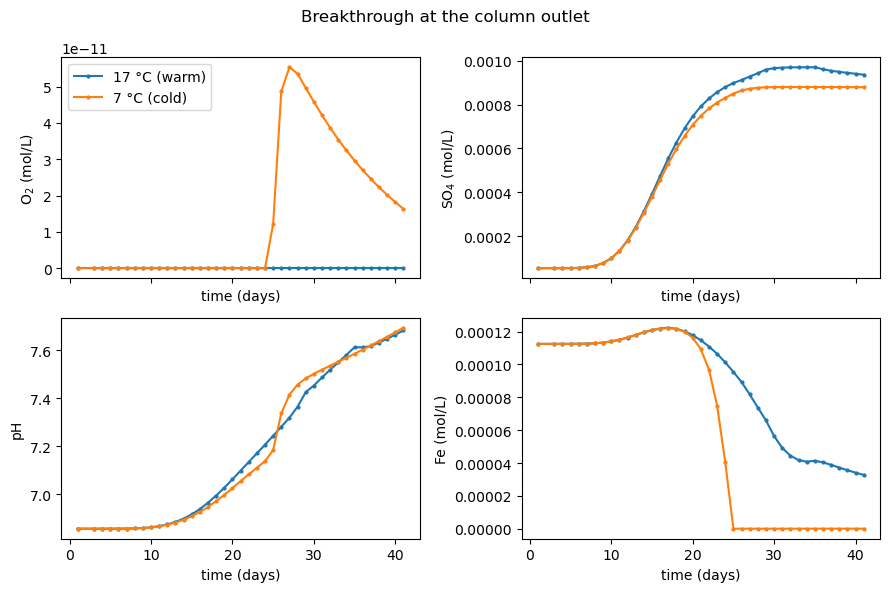

In [19]:
plot_breakthrough([warm, cold], ["17 °C (warm)", "7 °C (cold)"])
plt.show()


The warmer injectate oxidises pyrite faster, so it produces a higher sulfate plateau at the outlet; the colder run lags below it. The gap is modest here — a small column, a short run — but it is real and it points the right way. That gap is the temperature sensitivity of the forecast in miniature: a hint of why getting the temperature (and the pyrite rate it drives) right matters for the field-scale decision.

## Recap

We built a complete reactive-transport model from scratch and ran it in seconds:

- a 1D MODFLOW 6 **flow** model (inject at one end, fixed head at the other);
- **solutions**, **equilibrium phases** (calcite, ferrihydrite), a **kinetic phase** (pyrite), and an **exchanger**, assembled with `mup3d`;
- a **transport** model per chemical component, coupled to PHREEQC and run via the MODFLOW 6 / PHREEQC **API**;
- the outlet **breakthrough** of O₂, SO₄, pH and Fe, and its **temperature dependence**.

Every one of those steps reappears in [the full DIZON build](../part1_01_build_model/dizon_build_model.ipynb) — same API, same chemistry, just a real grid and a ~6 minute price tag per run. Keeping that price in mind is what motivates everything that follows: emulation, history matching on the cheap, and decision-support under uncertainty.